# Project Milestone One: Gathering your Team, Understanding the Problem,  Exploring the Data

#### Due: Midnight on March 29th (with 2-hour grace period)  

#### There will be no late period on this homework, as we need to start manual grading immediately! 



### What We Will Do in This Milestone Assignment

1. You will convene your team and fill out the Team Contract (in the Homework Repo), to be submitted to Gradescope.
2. You must select a team leader for the purpose of submitting this notebook, after the team collaborates to complete the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>link</a> describes how to add group members to your leader's submission. 
3. At the conclusion of your work on this Milestone, you will complete an Individual Evaluation of your team's work (in the Homework Repo) and upload it *individually* to Gradescope.
4. We will follow a simplified version of the **Machine Learning Project Checklist** in Appendix A in our textbook *Hands-On Machine Learning* (pp.779):  

>Part 1:	Frame the problem and look at the big picture  
Part 2: Download and perform preliminary exploration of the data  
Part 3: Clean the Data: Drop, Impute, and Encode   
Part 4: Explore Feature Relationships  
Part 5: Investigate Feature Engineering options to better expose the underlying data patterns  

### The Dataset

All teams will use the same dataset. It is a smaller version of the Zillow housing dataset that was used in the
Zillow Million Dollar Prize which ran on Kaggle in 2017 (sorry, the contest is closed, so you can't win any money
with this project!).  We will try to predict the assessed tax value (`'taxvaluedollarcnt'`) of the property from a large collection
of descriptors. Some features are closely related and some are obviously useless.  There are potential outliers and also quite a few missing values. 

This is a good example of a dataset which has not been predigested for you on Kaggle, and should give you a good chance to
try all the various tools in your toolbox!


In [1]:
# =============================
# Useful Imports
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Download the Zillow Housing Dataset 

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.** 

For a detailed description of the dataset features, please refer to  **Appendix 1** below. 

**Note:** Do **not** perform a train/test split for this milestone (unlike HOML suggests), since you need to do the split **after** any data preparation and feature engineering. You can wait until Milestone 2 to do the split. 

In [2]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File already exists. Skipping download.


## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercizing all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data; 
- Create a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:** 

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


**1.1:**  What is the objective of this project in business terms?

The objective is to build a data‑driven system that can estimate a property’s assessed tax value from available characteristics (size, location, quality, amenities, etc.). For Zillow, this supports more accurate and scalable valuation tools that can power customer‑facing products like price estimates, internal analytics on housing markets, and targeting for marketing campaigns. A reliable model helps reduce reliance on manual appraisals, improves consistency of valuations across regions, and ultimately supports better strategic decisions about where and how to focus Zillow’s products and advertising efforts.


**1.2:**  How will your solution be used?

The regression model would be used as an automated valuation tool that takes in the features of a property and outputs an estimated tax value. Product teams could surface these estimates directly to users browsing listings, to homeowners checking their equity, or to agents comparing similar homes in a neighborhood. Internally, analysts could run what‑if scenarios and quantify how feature changes affect value, and marketing could segment users based on estimated property value to design targeted campaigns or premium services such as refinancing.



**1.3:**  How should success (or failure) be measured?

Success should be measured by how close the model’s predicted tax values are to the actual assessed values on held‑out data, using metrics such as RMSE and MAE in dollar units so stakeholders can interpret typical errors. From a business perspective, we also care about the percentage of predictions that fall within an acceptable error band (for example, within ±10–15% of the true value), since large overestimates or underestimation can mislead customers. Failure would be indicated by large, systematic biases (e.g., consistently underpricing certain neighborhoods or high‑value homes), inconsistant performance across segments, or a model that is too complex or opaque to be trusted and maintained in production.


## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process. 
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [4]:


display(df.head())

df_info = df.info()

nunique_series = df.nunique(dropna=False).sort_values(ascending=False)
display(nunique_series)

missing_pct = df.isna().mean().sort_values(ascending=False) * 100
missing_summary = pd.DataFrame({
    "missing_pct": missing_pct,
    "nunique": nunique_series
})
display(missing_summary)

missing_summary.describe().T

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,...,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,6.059063e+13,1023282.0
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,...,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,6.111001e+13,464000.0
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,...,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,6.059022e+13,564778.0
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037300e+13,145143.0
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1964.0,NaN,NaN,2016.0,NaN,NaN,6.037124e+13,119407.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12          73923 non-null  float64
 13  f

parcelid                        77414
latitude                        64039
longitude                       62462
taxvaluedollarcnt               50950
rawcensustractandblock          39189
censustractandblock             39007
lotsizesquarefeet               18849
calculatedfinishedsquarefeet     4973
finishedsquarefeet12             4869
propertyzoningdesc               1908
finishedsquarefeet50             1808
finishedfloor1squarefeet         1788
finishedsquarefeet15             1725
garagetotalsqft                   840
yardbuildingsqft17                541
regionidneighborhood              481
regionidzip                       390
finishedsquarefeet6               351
poolsizesum                       263
regionidcity                      176
yearbuilt                         137
propertycountylandusecode          76
yardbuildingsqft26                 60
basementsqft                       44
bathroomcnt                        23
calculatedbathnbr                  22
bedroomcnt  

,missing_pct,nunique
airconditioningtypeid,67.779882,6
architecturalstyletypeid,99.733292,6
assessmentyear,0.043807,2
basementsqft,99.935578,44
bathroomcnt,0.043807,23
bedroomcnt,0.043807,17
buildingclasstypeid,99.980673,3
buildingqualitytypeid,35.823895,13
calculatedbathnbr,0.837489,22
calculatedfinishedsquarefeet,0.302784,4973


,count,mean,std,min,25%,50%,75%,max
missing_pct,55.0,50.915393,44.46429,0.0,0.205507,67.11891,97.466919,99.980673
nunique,55.0,6774.309091,18024.19779,2.0,5.000000,17.00000,690.500000,77414.000000


#### **2.A Discussion:** Answer the following questions.

**2.A.1:**  Which features are categorical?

Based on the data types and the feature descriptions, the  categorical features are `propertycountylandusecode`, `propertyzoningdesc`, and `taxdelinquencyflag`, which are stored as strings. Several integer ID fields are also categorical, for example `airconditioningtypeid`, `architecturalstyletypeid`, `buildingclasstypeid`, `buildingqualitytypeid`, `decktypeid`, `fips`, `heatingorsystemtypeid`, `propertylandusetypeid`, `rawcensustractandblock`, `regionidcity`, `regionidcounty`, `regionidneighborhood`, `regionidzip`, `storytypeid`, `typeconstructiontypeid`, and similar ID‑style columns. These IDs are just labels for groups or regions, so they should be treated as categorical in modeling even if they appear numeric in the dataframe.

**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly. 

Some features seem only to serve as identifiers and do not add meaningful information about the property’s value, so they are likely candidates to drop. For example, `parcelid` is a unique key that just labels each row, and `rawcensustractandblock` or `censustractandblock` are very granular geographic identifiers that are hard to interpret directly and may be redundant with higher‑level location features like `regionidcity`, `regionidzip`, and `regionidneighborhood`. Similarly, extremely sparse yard building square footage fields such as `yardbuildingsqft17` and `yardbuildingsqft26` may be too specific and noisy, so dropping them can simplify the feature without losing much useful signal.

**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example. 

There are several columns have extremely high proportions of missing values, which makes them hard to use reliably in a model. For example, features like `basementsqft`, `yardbuildingsqft17`, `yardbuildingsqft26` \, `architecturalstyletypeid`, `buildingclasstypeid`, `finishedsquarefeet13`,`fireplaceflag`, `poolsizesum`, `storytypeid`, `pooltypeid`, `taxdelinquencyflag` and `typeconstructiontypeid` are mostly null in this dataset. 

**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example. 

Features with almost one unique value per row behave like IDs and tend not to generalize well, especially if we would need to one‑hot encode them. For instance, `censustractandblock` or `rawcensustractandblock` can have thousands of distinct codes with only a handful of properties in each, which makes it hard for the model to learn reliable patterns. Similarly,  `parcelid` is unique for every property and not helpful as a predictor at all. 

### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization  

- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the **target and three (3)** other interesting-looking features in the dataset (i.e., a total of 4):  
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  

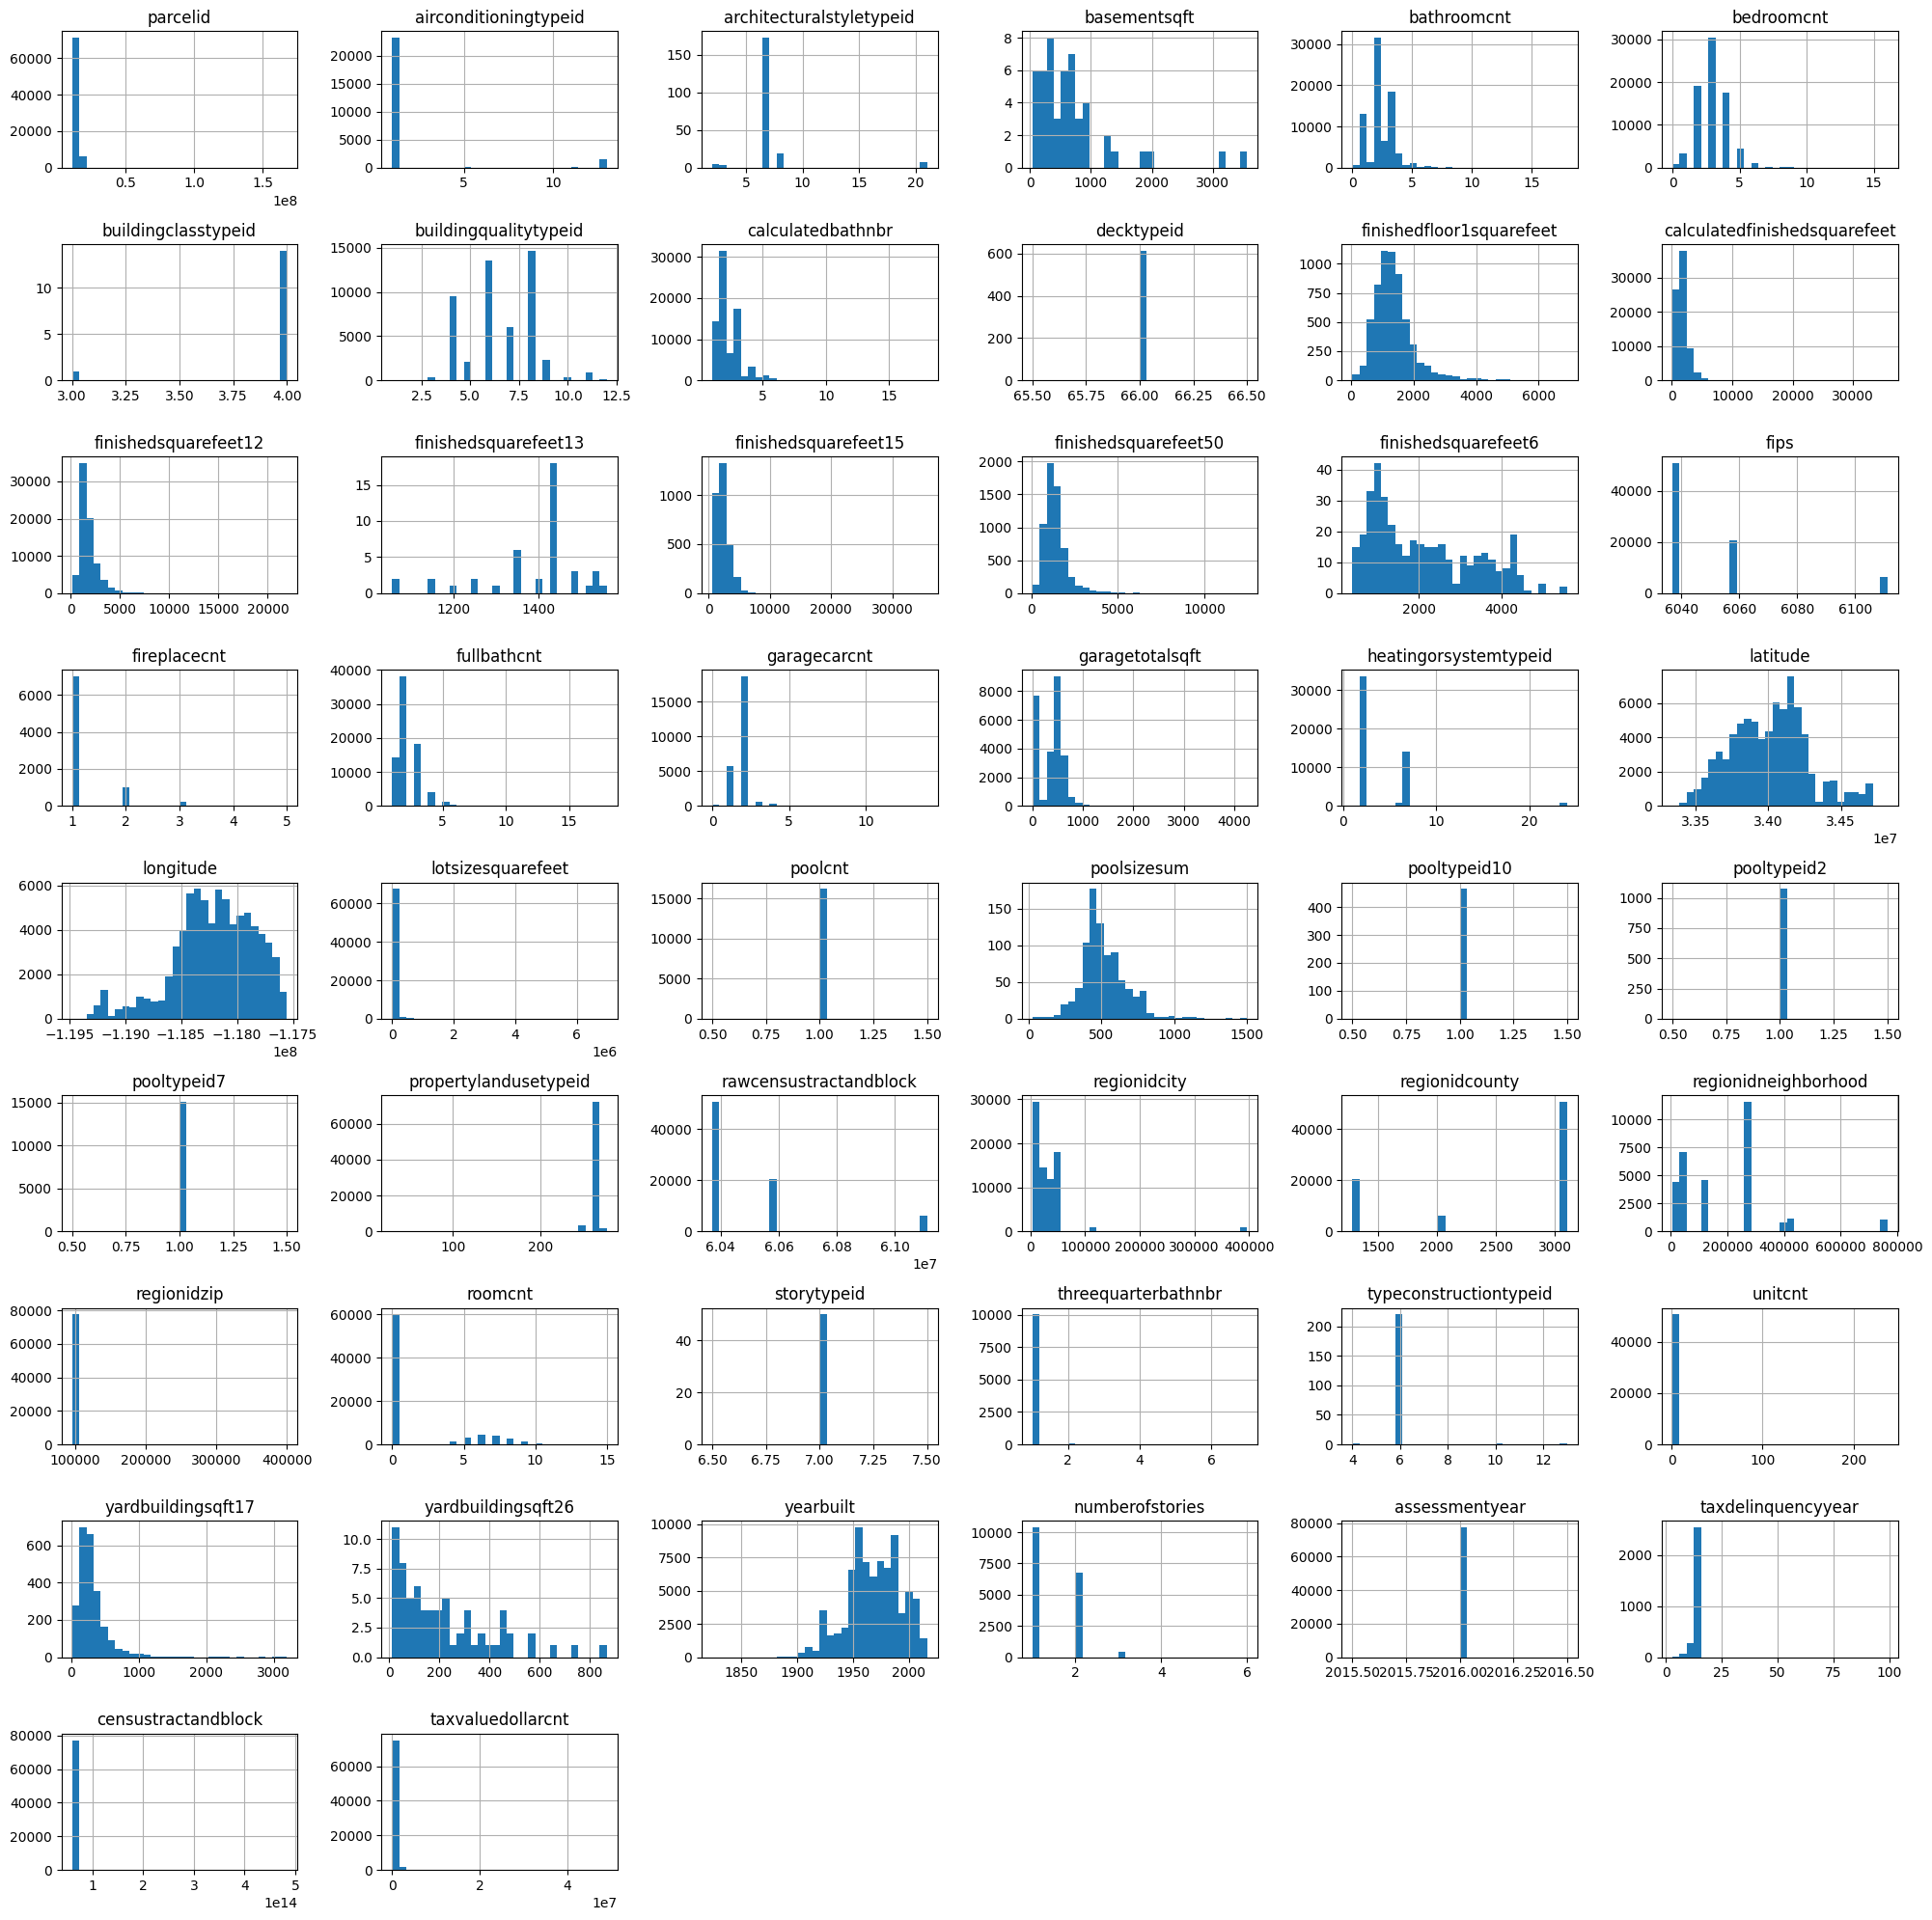

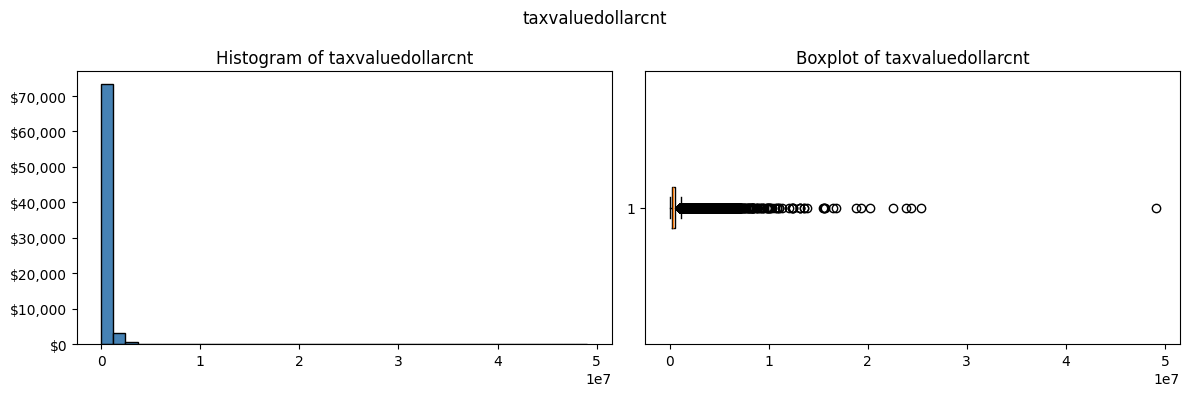

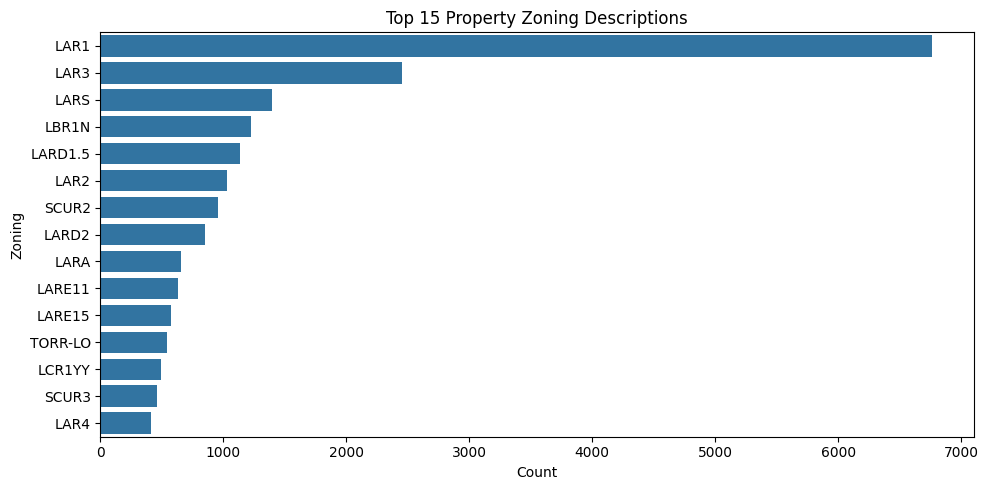

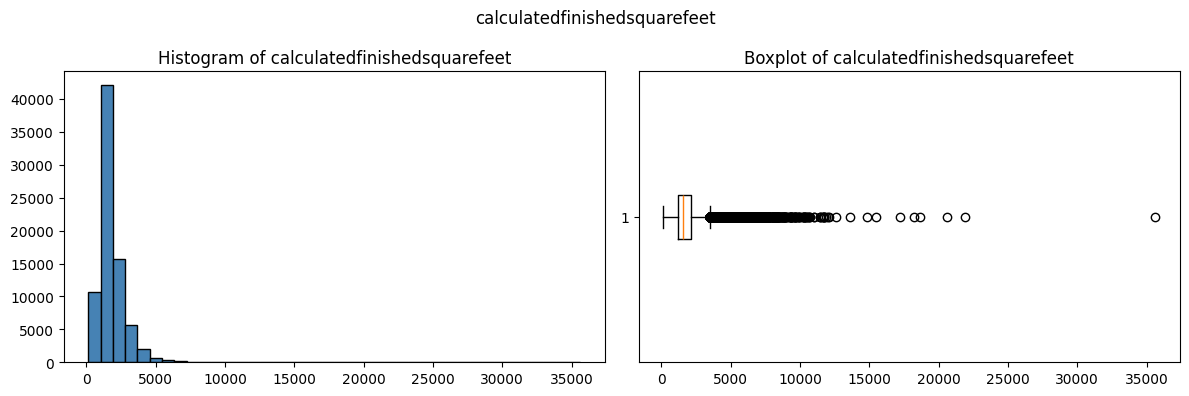

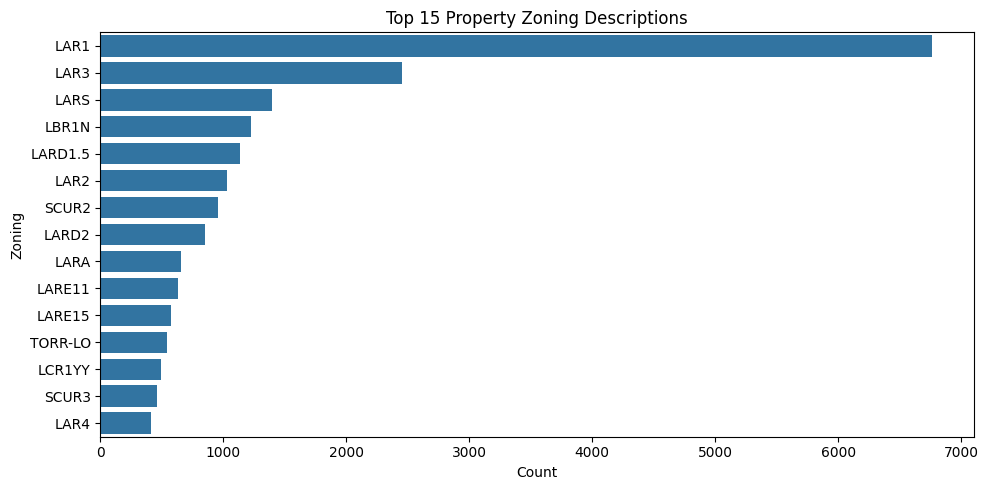

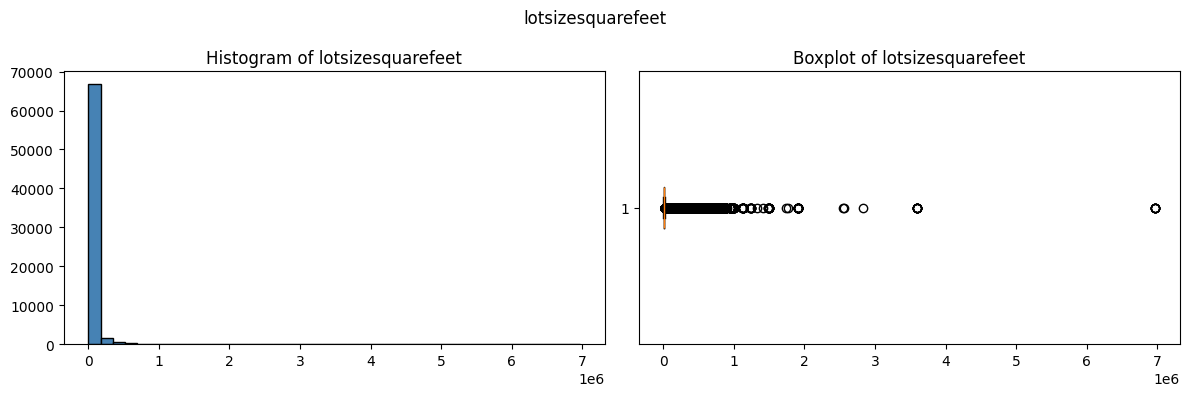

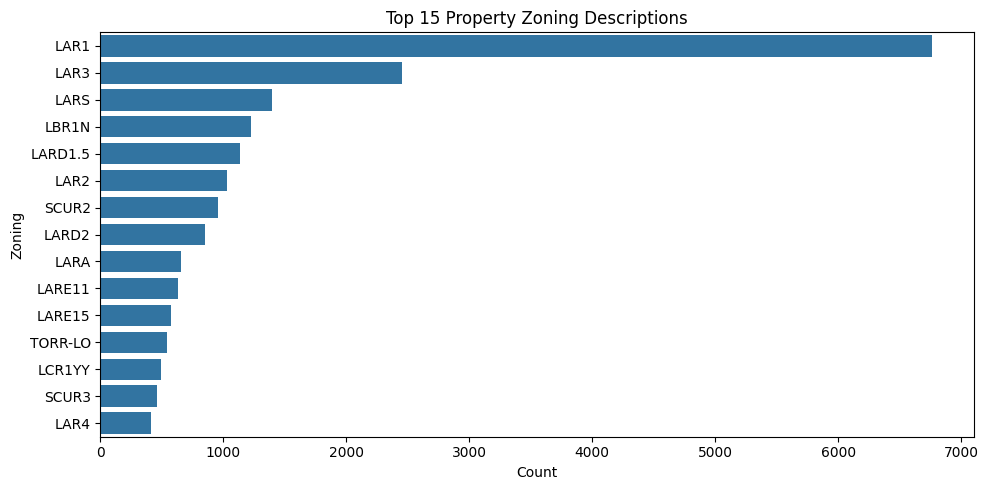

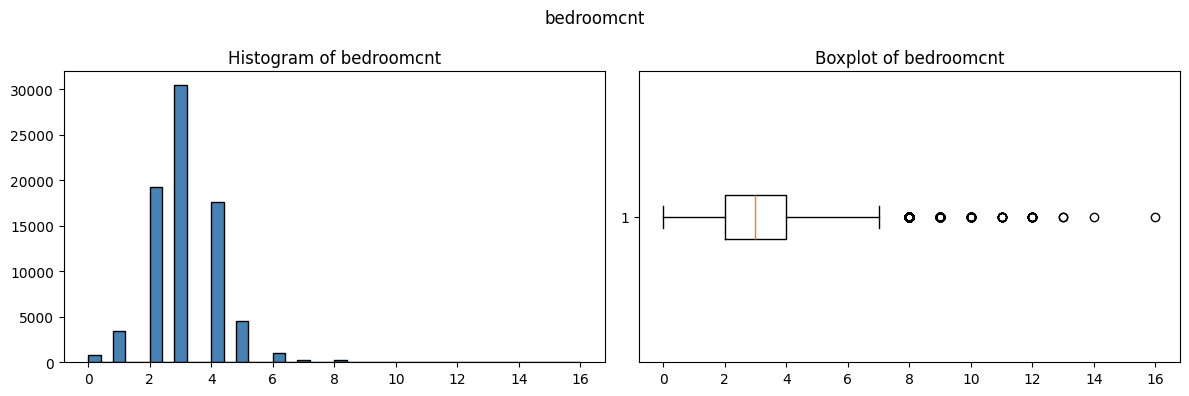

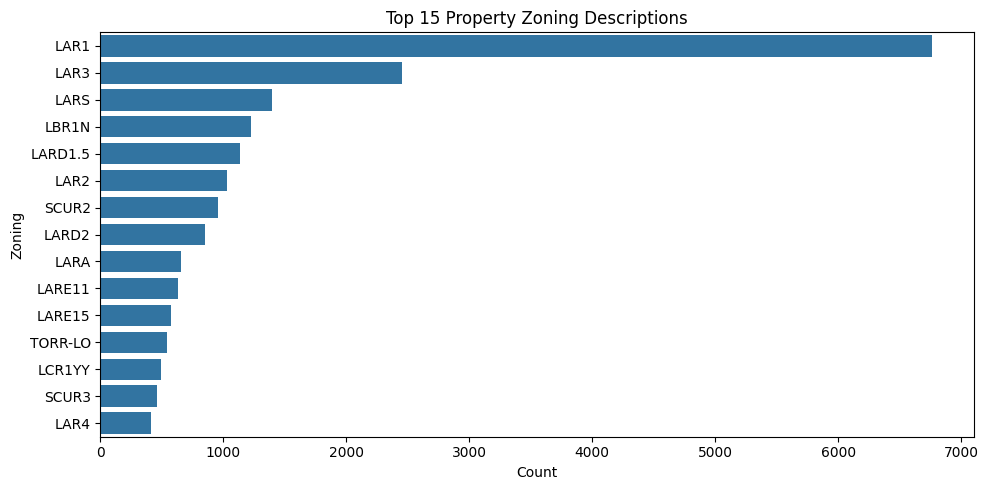

In [7]:
ax = df.hist(figsize=(20, 20), bins=30, layout=(-1, 6))
plt.tight_layout()
plt.show()


interesting_features = [
    "taxvaluedollarcnt",  # target
    "calculatedfinishedsquarefeet",
    "lotsizesquarefeet",
    "bedroomcnt",
]


for col in interesting_features:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    # Histogram
    axes[0].hist(df[col].dropna(), bins=40, color="steelblue", edgecolor="black")
    axes[0].set_title(f"Histogram of {col}")
    if col == "taxvaluedollarcnt":
        axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))
    # Boxplot
    axes[1].boxplot(df[col].dropna(), vert=False)
    axes[1].set_title(f"Boxplot of {col}")
    plt.suptitle(col)
    plt.tight_layout()
    plt.show()


    plt.figure(figsize=(10, 5))
    top_zones = df["propertyzoningdesc"].value_counts().head(15)
    sns.barplot(x=top_zones.values, y=top_zones.index, orient="h")
    plt.title("Top 15 Property Zoning Descriptions")
    plt.xlabel("Count")
    plt.ylabel("Zoning")
    plt.tight_layout()
    plt.show()

#### **2.B Discussion:** Describe in a paragraph what you learned in your detailed examination of the features you explored:
- What is the distribution (normal, exponential, etc.) if any?
- Any problems (e.g., outliers, any odd characteristics)?
- Anything else interesting? Why did you choose it?

From the histograms and boxplots, the target `taxvaluedollarcnt` is clearly right‑skewed with a long tail of very expensive properties. Log transformation might useful later. Additionally, Size‑related features like `calculatedfinishedsquarefeet` and `lotsizesquarefeet` also show heavy right skew and a few extreme outliers, while `bedroomcnt` is much more concentrated on small integer values with a few large properties having many bedrooms. The boxplots highlight that a small number of observations can be extremely far from the bulk of the data, which could influence the regression if we do not handle them carefully. 


## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task! 

In [8]:
zillow_clean = df.copy()
cols_to_drop_ids = [
    "parcelid",
    "rawcensustractandblock",
    "censustractandblock",
    "yardbuildingsqft17",
    "yardbuildingsqft26",
]
zillow_clean_3A = zillow_clean.drop(columns=cols_to_drop_ids, errors="ignore")
print("Original shape:", df.shape)
print("After Part 3.A drop:", zillow_clean_3A.shape)
zillow_clean_3A.head()

Original shape: (77613, 55)
After Part 3.A drop: (77613, 50)


,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,finishedfloor1squarefeet,...,threequarterbathnbr,typeconstructiontypeid,unitcnt,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,taxvaluedollarcnt
0,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,NaN,...,1.0,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,1023282.0
1,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,1465.0,...,NaN,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,464000.0
2,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,NaN,...,NaN,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,564778.0
3,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,NaN,...,NaN,NaN,1.0,1970.0,NaN,NaN,2016.0,NaN,NaN,145143.0
4,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,NaN,...,NaN,NaN,1.0,1964.0,NaN,NaN,2016.0,NaN,NaN,119407.0


#### **3.A Discussion:** Justify in a paragraph your decisions about which features to drop. 

I focused on dropping features that behave like  identifiers or extremely narrow technical codes, since they do not add interpretable information about value and can complicate the model. For example, `parcelid` is just a unique row key, so it cannot help predict new cases, and the very granular geographic codes `rawcensustractandblock` and `censustractandblock` duplicate location information already captured at higher levels by `regionidcity`, `regionidzip`, and related features. I also removed highly specific yard building square footage columns such as `yardbuildingsqft17` and `yardbuildingsqft26`, which appear quite sparse and represent unusual structures that are unlikely to generalize well. 


### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully. 

In [9]:


zillow_clean_3B = zillow_clean_3A.copy()
missing_pct_3B = zillow_clean_3B.isna().mean() * 100

threshold_col_missing = 60.0
cols_to_drop_3B = missing_pct_3B[missing_pct_3B > threshold_col_missing].index.tolist()

print(cols_to_drop_3B)

zillow_clean_3B = zillow_clean_3B.drop(columns=cols_to_drop_3B)


zillow_clean_3B.head()

['airconditioningtypeid', 'architecturalstyletypeid', 'basementsqft', 'buildingclasstypeid', 'decktypeid', 'finishedfloor1squarefeet', 'finishedsquarefeet13', 'finishedsquarefeet15', 'finishedsquarefeet50', 'finishedsquarefeet6', 'fireplacecnt', 'garagecarcnt', 'garagetotalsqft', 'hashottuborspa', 'poolcnt', 'poolsizesum', 'pooltypeid10', 'pooltypeid2', 'pooltypeid7', 'regionidneighborhood', 'storytypeid', 'threequarterbathnbr', 'typeconstructiontypeid', 'numberofstories', 'fireplaceflag', 'taxdelinquencyflag', 'taxdelinquencyyear']


,bathroomcnt,bedroomcnt,buildingqualitytypeid,calculatedbathnbr,calculatedfinishedsquarefeet,finishedsquarefeet12,fips,fullbathcnt,heatingorsystemtypeid,latitude,...,propertylandusetypeid,propertyzoningdesc,regionidcity,regionidcounty,regionidzip,roomcnt,unitcnt,yearbuilt,assessmentyear,taxvaluedollarcnt
0,3.5,4.0,NaN,3.5,3100.0,3100.0,6059.0,3.0,NaN,33634931.0,...,261.0,NaN,53571.0,1286.0,96978.0,0.0,NaN,1998.0,2016.0,1023282.0
1,1.0,2.0,NaN,1.0,1465.0,1465.0,6111.0,1.0,NaN,34449266.0,...,261.0,NaN,13091.0,2061.0,97099.0,5.0,NaN,1967.0,2016.0,464000.0
2,2.0,3.0,NaN,2.0,1243.0,1243.0,6059.0,2.0,NaN,33886168.0,...,261.0,NaN,21412.0,1286.0,97078.0,6.0,NaN,1962.0,2016.0,564778.0
3,3.0,4.0,8.0,3.0,2376.0,2376.0,6037.0,3.0,2.0,34245180.0,...,261.0,LCR110000*,396551.0,3101.0,96330.0,0.0,1.0,1970.0,2016.0,145143.0
4,3.0,3.0,8.0,3.0,1312.0,1312.0,6037.0,3.0,2.0,34185120.0,...,266.0,LAR3,12447.0,3101.0,96451.0,0.0,1.0,1964.0,2016.0,119407.0


#### **3.B Discussion:** In a paragraph, explain your decision about which features were dropped

To control the amount of missing data the model has to deal with, I dropped features where more than about 60% of the entries were null. Above this level, there is relatively little observed information to learn from, and any imputation would be highly speculative and might inject noise rather than signal. 


### Part 3.C: Drop Problematic **samples** 

There could be several reasons why you might want to drop a sample:
- It has  "too many" null values 
- It has a null value in the target
- It contains outliers, especially in the target



Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


In [11]:
zillow_clean_3C = zillow_clean_3B.copy()

TARGET = "taxvaluedollarcnt"
# Rows with no target cannot be used
zillow_clean_3C = zillow_clean_3C.dropna(subset=[TARGET])

# Rows with too many missing features
feature_cols = [c for c in zillow_clean_3C.columns if c != TARGET]
max_missing_pct = 50.0

pct_missing = zillow_clean_3C[feature_cols].isna().mean(axis=1) * 100
sparse_row = pct_missing > max_missing_pct

n_sparse = sparse_row.sum()
zillow_clean_3C = zillow_clean_3C.loc[~sparse_row].copy()

# Extreme target values 
q_low, q_high = 0.01, 0.99
low_val = zillow_clean_3C[TARGET].quantile(q_low)
high_val = zillow_clean_3C[TARGET].quantile(q_high)

n_before_outliers = len(zillow_clean_3C)
in_quantile_band = zillow_clean_3C[TARGET].between(low_val, high_val)
zillow_clean_3C = zillow_clean_3C.loc[in_quantile_band].copy()

n_outliers = n_before_outliers - len(zillow_clean_3C)

zillow_clean_3C[TARGET].describe()

count    7.602600e+04
mean     4.512660e+05
std      3.774619e+05
min      3.970900e+04
25%      2.100840e+05
50%      3.588785e+05
75%      5.627720e+05
max      2.758703e+06
Name: taxvaluedollarcnt, dtype: float64

#### **3.C Discussion:** In a short paragraph, explain your decision about which samples were dropped

First, I removed any rows where the target `taxvaluedollarcnt` was missing, since we cannot learn from or evaluate those examples in a regression. Next, I filtered out samples with more than roughly half of their feature values missing, because such rows would require very heavy imputation and are likely to be unreliable. Finally, I trimmed extreme outliers in the target by removing the top and bottom 1% of values; these very unusual properties can dominate the loss and make it harder for the model to fit the bulk of the market. 

### Part 3.D: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Answer the discussion question.

In [13]:
zillow_clean_3D = zillow_clean_3C.copy()

TARGET = "taxvaluedollarcnt"
y = zillow_clean_3D[TARGET].values
X = zillow_clean_3D.drop(columns=[TARGET]).copy()

NOMINAL_CODE_COLS = [
    "regionidcity",
    "regionidcounty",
    "regionidzip",
    "fips",
    "propertylandusetypeid",
    "buildingqualitytypeid",
    "heatingorsystemtypeid",
]

for col in NOMINAL_CODE_COLS:
    if col not in X.columns:
        continue
    X[col] = X[col].apply(lambda v: str(int(v)) if pd.notna(v) else np.nan)

cat_cols = [c for c in X.columns if X[c].dtype == "object"]
num_cols = [c for c in X.columns if c not in cat_cols]


print("Number of numeric features:", len(num_cols))
print("Number of categorical features:", len(cat_cols))

num_imputer = SimpleImputer(strategy="median")
X_num = pd.DataFrame(
    num_imputer.fit_transform(X[num_cols]),
    columns=num_cols,
    index=X.index,
)

if cat_cols:
    cat_imputer = SimpleImputer(strategy="most_frequent")
    X_cat_array = cat_imputer.fit_transform(X[cat_cols])
    X_cat = pd.DataFrame(X_cat_array, columns=cat_cols, index=X.index)
    # As a safeguard, fill any remaining NaNs with "Unknown"
    X_cat = X_cat.fillna("Unknown")
    X_imputed = pd.concat([X_num, X_cat], axis=1)
else:
    X_imputed = X_num

zillow_imputed = X_imputed.copy()
zillow_imputed[TARGET] = y


zillow_imputed.head()

Number of numeric features: 13
Number of categorical features: 9


,bathroomcnt,bedroomcnt,calculatedbathnbr,calculatedfinishedsquarefeet,finishedsquarefeet12,fullbathcnt,latitude,longitude,lotsizesquarefeet,roomcnt,...,buildingqualitytypeid,fips,heatingorsystemtypeid,propertycountylandusecode,propertylandusetypeid,propertyzoningdesc,regionidcity,regionidcounty,regionidzip,taxvaluedollarcnt
0,3.5,4.0,3.5,3100.0,3100.0,3.0,33634931.0,-117869207.0,4506.0,0.0,...,8,6059,2,122,261,LAR1,53571,1286,96978,1023282.0
1,1.0,2.0,1.0,1465.0,1465.0,1.0,34449266.0,-119281531.0,12647.0,5.0,...,8,6111,2,1110,261,LAR1,13091,2061,97099,464000.0
2,2.0,3.0,2.0,1243.0,1243.0,2.0,33886168.0,-117823170.0,8432.0,6.0,...,8,6059,2,122,261,LAR1,21412,1286,97078,564778.0
3,3.0,4.0,3.0,2376.0,2376.0,3.0,34245180.0,-118240722.0,13038.0,0.0,...,8,6037,2,0101,261,LCR110000*,396551,3101,96330,145143.0
4,3.0,3.0,3.0,1312.0,1312.0,3.0,34185120.0,-118414640.0,278581.0,0.0,...,8,6037,2,010C,266,LAR3,12447,3101,96451,119407.0


#### **3.D Discussion:**  Describe in a paragraph your decisions about which methods you used to impute missing values in the dataset

For numerical features, I chose median imputation because many of the size and value‑related variables are right‑skewed and can contain outliers; the median is more robust than the mean in this situation and preserves the central tendency without being dominated by extreme values. For categorical features, I used the mode to fill in missing entries, which reflects the idea that if we do not know the category, we assume the most typical one, and then I fell back to an explicit `"Unknown"` label if anything remained missing. 


### 3.E: Encode the Categorical Features (if any)

You may not have any categorical features. If you do, encode them in the next step. No discussion is necessary. 

In [14]:
# Part 3.E: Encode categorical features

zillow_encoded = zillow_imputed.copy()

# Identify categorical columns again (after imputation)
cat_cols_encoded = [c for c in zillow_encoded.columns if zillow_encoded[c].dtype == "object" and c != "taxvaluedollarcnt"]
num_cols_encoded = [c for c in zillow_encoded.columns if c not in cat_cols_encoded and c != "taxvaluedollarcnt"]

print("Categorical columns to encode:", cat_cols_encoded)

if cat_cols_encoded:
    # Use an ordinal encoding for now; later we could switch to one‑hot if needed
    encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    zillow_encoded[cat_cols_encoded] = encoder.fit_transform(zillow_encoded[cat_cols_encoded])

print("Encoded dataframe shape:", zillow_encoded.shape)

zillow_encoded.head()

Categorical columns to encode: ['buildingqualitytypeid', 'fips', 'heatingorsystemtypeid', 'propertycountylandusecode', 'propertylandusetypeid', 'propertyzoningdesc', 'regionidcity', 'regionidcounty', 'regionidzip']
Encoded dataframe shape: (76026, 23)


,bathroomcnt,bedroomcnt,calculatedbathnbr,calculatedfinishedsquarefeet,finishedsquarefeet12,fullbathcnt,latitude,longitude,lotsizesquarefeet,roomcnt,...,buildingqualitytypeid,fips,heatingorsystemtypeid,propertycountylandusecode,propertylandusetypeid,propertyzoningdesc,regionidcity,regionidcounty,regionidzip,taxvaluedollarcnt
0,3.5,4.0,3.5,3100.0,3100.0,3.0,33634931.0,-117869207.0,4506.0,0.0,...,10.0,1.0,5.0,55.0,4.0,573.0,156.0,0.0,304.0,1023282.0
1,1.0,2.0,1.0,1465.0,1465.0,1.0,34449266.0,-119281531.0,12647.0,5.0,...,10.0,2.0,5.0,46.0,4.0,573.0,26.0,1.0,365.0,464000.0
2,2.0,3.0,2.0,1243.0,1243.0,2.0,33886168.0,-117823170.0,8432.0,6.0,...,10.0,1.0,5.0,55.0,4.0,573.0,52.0,0.0,353.0,564778.0
3,3.0,4.0,3.0,2376.0,2376.0,3.0,34245180.0,-118240722.0,13038.0,0.0,...,10.0,0.0,5.0,1.0,4.0,786.0,117.0,2.0,187.0,145143.0
4,3.0,3.0,3.0,1312.0,1312.0,3.0,34185120.0,-118414640.0,278581.0,0.0,...,10.0,0.0,5.0,8.0,8.0,580.0,23.0,2.0,241.0,119407.0


## Part 4:  Investigate Feature Relationships  [6 pts]

In this part, we will investigate the feature relationships as a way of understanding the data.  In the next part, we'll investigate potential feature engineering opportunities.

**Note:**  We won't be committing to any changes to the data until Milestone 2, as our choice of transformations will very much depend on the model we're building. But investigating these aspects of the data is an essential step in the first stages of our project. 

### Part 4.A:

   - Compute and analyze pairwise correlations using a correlation matrix.
   - Compute the F-statistic for all features for a better view of the relationships (displaying them in a bar chart would be useful as well). 
   - Identify features with strong correlations or notable relationships that may impact model performance.
   - Investigate forward and backward feature selection
        - Run these algorithms to investigate possible feature selection (don't commit to any selections yet)

Your code below, in multiple cells with descriptive comments. 

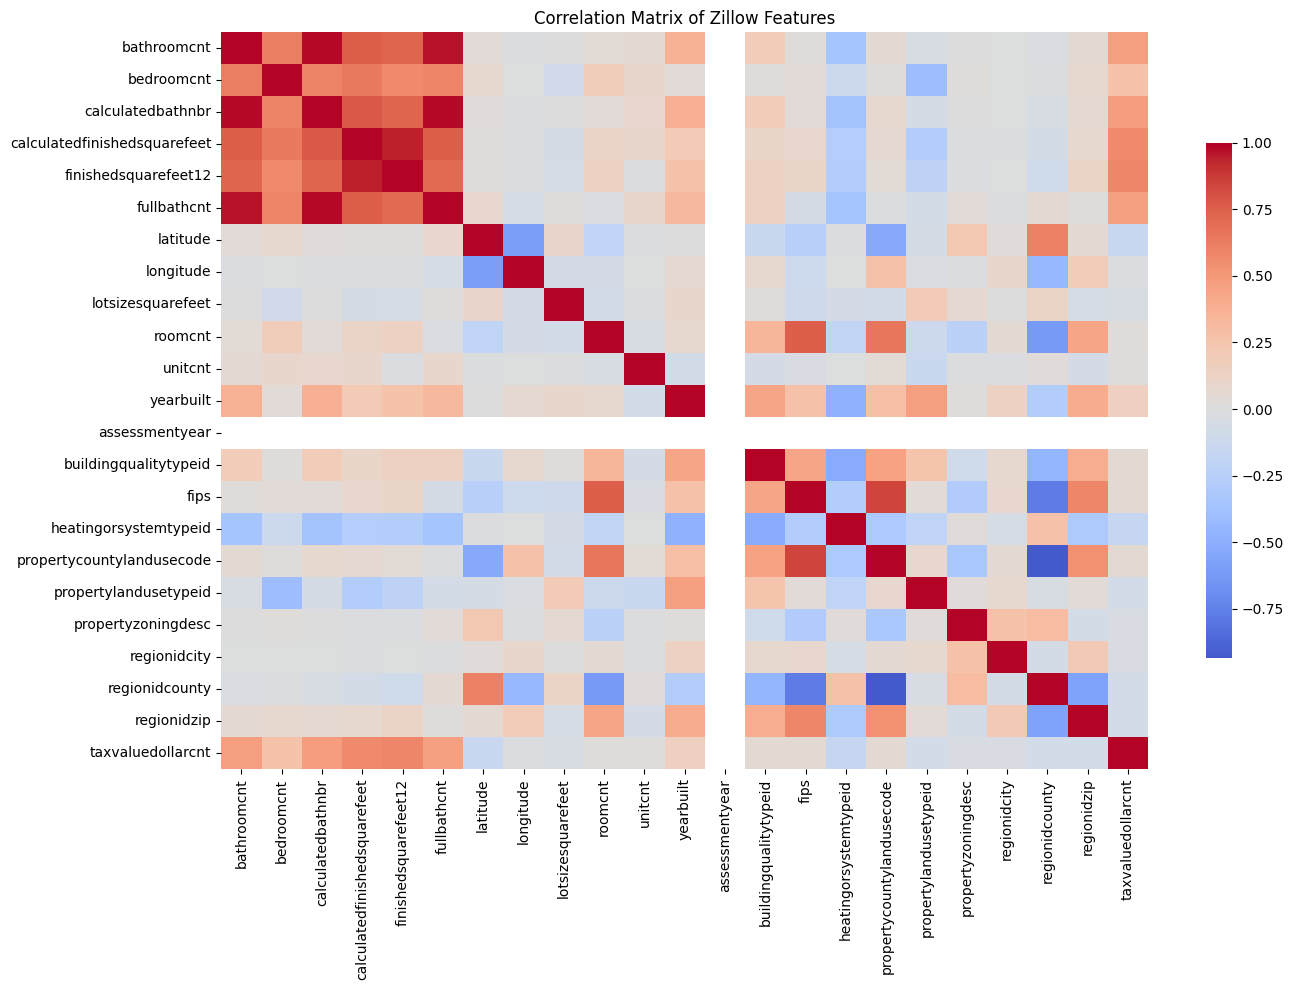

Top 10 positive correlations with target:
finishedsquarefeet12            0.588026
calculatedfinishedsquarefeet    0.575283
calculatedbathnbr               0.484485
bathroomcnt                     0.470956
fullbathcnt                     0.463047
bedroomcnt                      0.260387
yearbuilt                       0.158819
buildingqualitytypeid           0.053505
propertycountylandusecode       0.053424
fips                            0.053366
Name: taxvaluedollarcnt, dtype: float64

Top 10 negative correlations with target:
longitude               -0.014622
regionidcity            -0.031664
propertyzoningdesc      -0.034184
lotsizesquarefeet       -0.039748
propertylandusetypeid   -0.080062
regionidcounty          -0.082981
regionidzip             -0.085285
latitude                -0.146688
heatingorsystemtypeid   -0.160734
assessmentyear                NaN
Name: taxvaluedollarcnt, dtype: float64


,feature,F_score,p_value
4,finishedsquarefeet12,40180.512975,0.000000e+00
3,calculatedfinishedsquarefeet,37605.813073,0.000000e+00
2,calculatedbathnbr,23318.198403,0.000000e+00
0,bathroomcnt,21668.012373,0.000000e+00
5,fullbathcnt,20749.388593,0.000000e+00
1,bedroomcnt,5529.413858,0.000000e+00
15,heatingorsystemtypeid,2016.200629,0.000000e+00
11,yearbuilt,1967.201794,0.000000e+00
6,latitude,1671.815285,0.000000e+00
21,regionidzip,557.012346,1.040088e-122


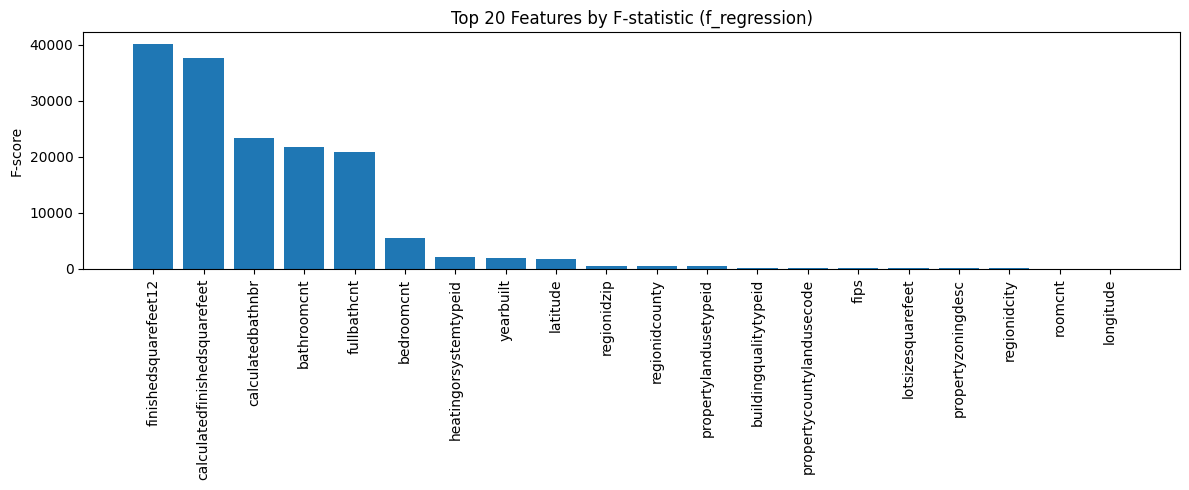

Forward selection chose:
['finishedsquarefeet12', 'calculatedfinishedsquarefeet', 'calculatedbathnbr', 'bedroomcnt', 'propertycountylandusecode', 'roomcnt', 'longitude', 'regionidcounty', 'regionidzip', 'latitude']

Backward selection chose:
['finishedsquarefeet12', 'calculatedfinishedsquarefeet', 'bathroomcnt', 'bedroomcnt', 'propertycountylandusecode', 'roomcnt', 'longitude', 'regionidcounty', 'regionidzip', 'latitude']


In [15]:

y = zillow_encoded["taxvaluedollarcnt"].values
X = zillow_encoded.drop(columns=["taxvaluedollarcnt"])

correlation_matrix = zillow_encoded.corr(numeric_only=True)
plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    cbar_kws={"shrink": 0.7},
)
plt.title("Correlation Matrix of Zillow Features")
plt.tight_layout()
plt.show()

# Look at top correlations with the target
target_corr = correlation_matrix["taxvaluedollarcnt"].drop("taxvaluedollarcnt").sort_values(ascending=False)
print("Top 10 positive correlations with target:")
print(target_corr.head(10))
print("\nTop 10 negative correlations with target:")
print(target_corr.tail(10))

# 2) F-statistics using SelectKBest with f_regression
selector = SelectKBest(score_func=f_regression, k="all")
selector.fit(X, y)

f_scores = selector.scores_
p_values = selector.pvalues_

f_df = pd.DataFrame({
    "feature": X.columns,
    "F_score": f_scores,
    "p_value": p_values,
}).sort_values("F_score", ascending=False)

display(f_df.head(15))

plt.figure(figsize=(12, 5))
plt.bar(f_df["feature"].head(20), f_df["F_score"].head(20))
plt.xticks(rotation=90)
plt.title("Top 20 Features by F-statistic (f_regression)")
plt.ylabel("F-score")
plt.tight_layout()
plt.show()

from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

max_features_for_sfs = min(25, X.shape[1])
selected_for_sfs = target_corr.index[:max_features_for_sfs]
X_sfs = X[selected_for_sfs]


sfs_forward = SequentialFeatureSelector(
    lin_reg,
    n_features_to_select=min(10, X_sfs.shape[1]),
    direction="forward",
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
)

sfs_forward.fit(X_sfs, y)
forward_selected_features = list(X_sfs.columns[sfs_forward.get_support()])
print("Forward selection chose:")
print(forward_selected_features)


sfs_backward = SequentialFeatureSelector(
    lin_reg,
    n_features_to_select=min(10, X_sfs.shape[1]),
    direction="backward",
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
)

sfs_backward.fit(X_sfs, y)
backward_selected_features = list(X_sfs.columns[sfs_backward.get_support()])
print("\nBackward selection chose:")
print(backward_selected_features)

#### **4.A Discussion:**  Describe in a paragraph what you see in the feature relationships and correlations.

Pay particular attention to especially interesting and/or strongly correlated feature relationships. 
 How do the different methods for seeing relationships compare? Do they agree or disagree?

From the correlation matrix and the sorted correlation list, the strongest positive relationships with `taxvaluedollarcnt` are generally size‑ and quality‑related features such as `calculatedfinishedsquarefeet`, total finished square footage variants, room counts, and sometimes location‑related indices, which matches intuition that bigger and better homes tend to be more valuable. The F‑statistics from `f_regression`. Forward and backward sequential feature selection with a linear model also tend to choose overlapping subsets of these features, although the exact selections differ slightly. Overall, these different methods largely agree on the core drivers of value, while the small disagreements remind us that correlated predictors can be somewhat interchangeable in a linear regression setting.

### Part 4.B:  2-Dimensional Visualizations for Interesting Patterns  
   - Select three (3) pairs of features that exhibit meaningful relationships based on your previous analysis. 
   - Create 2D scatter plots or density plots to explore interactions between these features.  
   - Provide brief interpretations of any observed patterns or trends. 

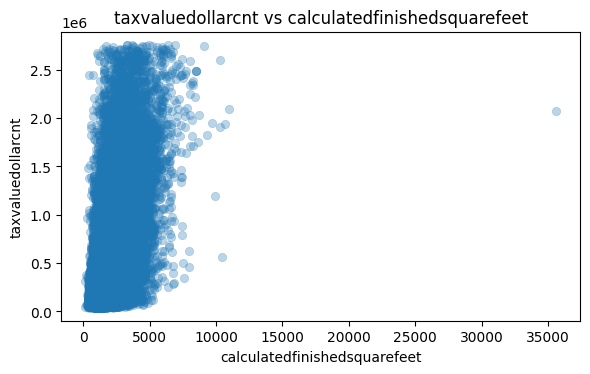

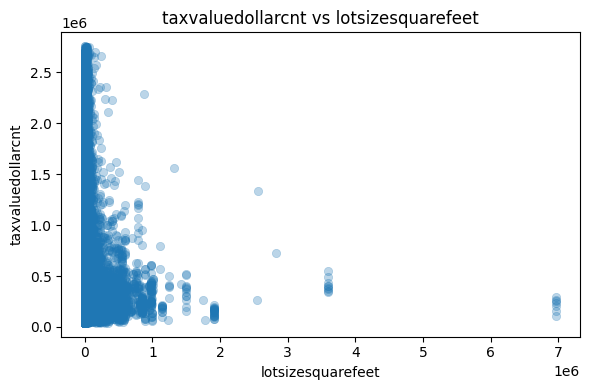

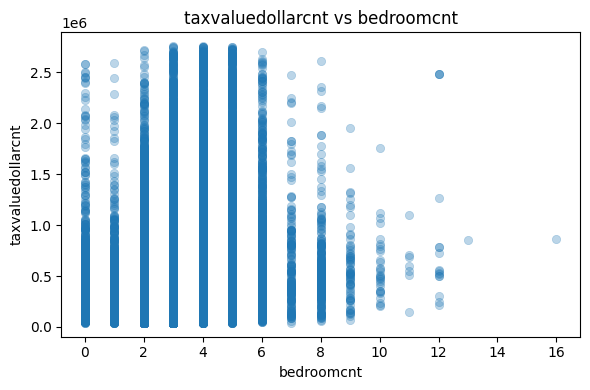

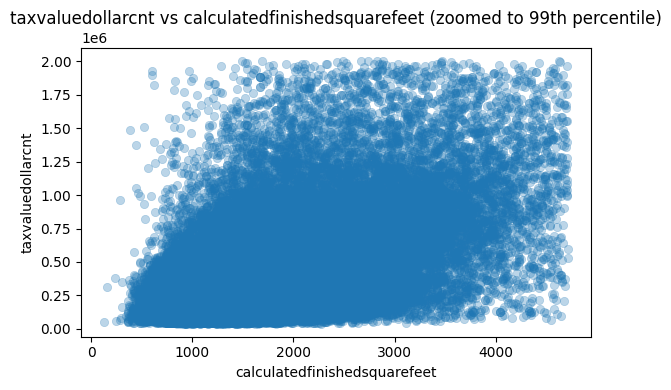

In [16]:

pairs = [
    ("calculatedfinishedsquarefeet", "taxvaluedollarcnt"),
    ("lotsizesquarefeet", "taxvaluedollarcnt"),
    ("bedroomcnt", "taxvaluedollarcnt"),
]

for x_col, y_col in pairs:
    if x_col in zillow_encoded.columns and y_col in zillow_encoded.columns:
        plt.figure(figsize=(6, 4))
        sns.scatterplot(
            x=zillow_encoded[x_col],
            y=zillow_encoded[y_col],
            alpha=0.3,
            edgecolor=None,
        )
        plt.xlabel(x_col)
        plt.ylabel(y_col)
        plt.title(f"{y_col} vs {x_col}")
        plt.tight_layout()
        plt.show()

# Optional: zoom in on the main mass of the data for one pair to reduce the effect of outliers
x_col, y_col = "calculatedfinishedsquarefeet", "taxvaluedollarcnt"
if x_col in zillow_encoded.columns and y_col in zillow_encoded.columns:
    x_q_high = zillow_encoded[x_col].quantile(0.99)
    y_q_high = zillow_encoded[y_col].quantile(0.99)
    mask = (zillow_encoded[x_col] <= x_q_high) & (zillow_encoded[y_col] <= y_q_high)

    plt.figure(figsize=(6, 4))
    sns.scatterplot(
        x=zillow_encoded.loc[mask, x_col],
        y=zillow_encoded.loc[mask, y_col],
        alpha=0.3,
        edgecolor=None,
    )
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"{y_col} vs {x_col} (zoomed to 99th percentile)")
    plt.tight_layout()
    plt.show()

#### **4.B Discussion:** Provide brief interpretations of any observed patterns or trends.

In the scatter plots, `taxvaluedollarcnt` increases with `calculatedfinishedsquarefeet`, though the relationship is noisy and clearly not perfectly linear; larger homes tend to be worth more, but there is a lot of spread, likely due to location, quality, and lot size. The plot of `taxvaluedollarcnt` versus `lotsizesquarefeet` shows a weaker but still positive trend. For `bedroomcnt`, the pattern is going from very few to a moderate number of bedrooms is associated with higher values, but beyond a certain point the additional bedrooms add less incremental value and the points spread out more. Zooming into the central mass of the data emphasizes that most properties lie in a relatively narrow band of sizes and values.


## Part 5:  Feature Engineering: Investigate various transformations to better expose the underlying data patterns to machine learning algorithms. [6 pts]

**Important Notes:**  
- This last part is a bit open ended, since there is a huge variety of feature engineering techniques, most of which won't be useful for your particular dataset. 
- Understand that you can't evaluate the final usefulness of these transformations
until you choose a model, and  models may respond differently to various transformations or obviate some transformations (e.g., ensemble methods already do feature selection). 
- Therefore, write your transformations as functions or otherwise be prepared
to choose later on which transformations may be necessary. 

**Investigate feature engineering, where appropriate:**

- Feature scaling: standardize or normalize features as necessary
- Decompose features (e.g., categorical into One-Hot feature sequence, date/time into two features data and time, etc.).
- Add promising transformations of features
    - Exponential $\exp(x_i)$ or logarithmic $\log(x_j)$
    - Polynomial features  ( $x_i^2$, $x_i - x_j$), products ($x_i*x_j$), or ratios ($x_i/x_j$)

**ToDo:**
- Pick at least three transformations to try.
- Try each one and evaluate its effect using correlations or F-scores or a feature selection algorithm.
- Answer the discussion question. 

## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |

